# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Selvakumar Sanjeth



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [2]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Business Understanding
Goal: Predict whether a patient has heart disease or not bassed on clinical characteristics of the patient.

**Dataset Context:**
For this project, I am using the UCI Heart Disease Dataset. It contains clinical test results from patients (such as resting blood pressure, cholesterol levels). The objective is to translate the real-world medical measurements into a reliable risk result. By predicting the presence of heart disease accurately, this model could assist medical professionals in prioritizing high-risk patients and will be an early intervention.

# 2. Data Understanding

### Data Dictionary: Column Definitions and Explanations

* **id**: Patient Identification Number (Unique ID)
* **age**: Age of the patient in years
* **sex**: Gender/Sex of the patient (Male or Female)
* **dataset**: Location of the study where the data was collected (e.g., Cleveland, Hungary)
* **cp**: Chest Pain Type (e.g., typical angina, atypical angina, non-anginal pain, or asymptomatic)
* **trestbps**: Resting Blood Pressure (measured in mm Hg upon hospital admission)
* **chol**: Serum Cholesterol measure (measured in mg/dl)
* **fbs**: Fasting Blood Sugar (indicates if fasting blood sugar is greater than 120 mg/dl; True or False)
* **restecg**: Resting Electrocardiographic (ECG) results
* **thalch**: Maximum Heart Rate Achieved during physical testing
* **exang**: Exercise-Induced Angina (indicates if chest pain is brought on by exercise; True or False)
* **oldpeak**: ST depression induced by exercise relative to rest (an abnormalities check measured via ECG)
* **slope**: The slope of the peak exercise ST segment on an ECG
* **ca**: Number of major blood vessels (0–3) colored by a medical scan called fluoroscopy
* **thal**: Thalassemia status (a genetic blood condition type)
* **num**: Target variable / Diagnosis of heart disease status (0 = no heart disease, 1, 2, 3, 4 = progressive stages of heart disease)

imfo of the data set

## 2.1 Load dataset

In [3]:
## Read *.csv file into pandas DataFrame
FILE_PATH = "heart_disease_uci.csv"
df = pd.read_csv(FILE_PATH)
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


## 2.2 Summary Statistics

In [4]:
## Number of rows and columns in the DataFrame
df.shape


(920, 16)

In [5]:
## Get information about the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 156.4+ KB


In [6]:
## Check for missing data(Shows the amount whats not a number)(NaN Count)
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [7]:
## Describe data distribution
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [8]:
## Check the distribution of num
df['num'].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

add understanding for distribution and outliers and the data for boxplot and other graphs
gotta explain the graphs

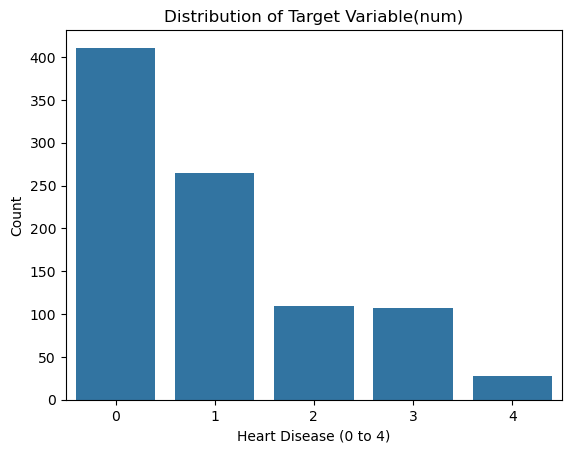

In [9]:
## Count for the distribution of num
sns.countplot(data=df, x='num')
plt.title('Distribution of Target Variable(num)')
plt.xlabel('Heart Disease (0 to 4)')
plt.ylabel('Count')
plt.show()

**Target Distribution Analysis:**
The countplot above visualizes the distribution of the target variable (num), which categorizes heart disease severity from 0 (Healthy) to 4 (Severe). As the graph shows, '0' has the highest patient count and the frequency steadily decreases as the disease severity reaches stage 4. 

This tells that the "sick" patients are spread across four different sub-categories, which would make it difficult for a machine learning model to learn effectively. So, I will group stages 1 through 4 together into a single "Heart Disease Present" category (1). This will change the spreaded data into a clear, well-balanced binary classification problem.

### 2.3.1.2 Understanding distribution of features

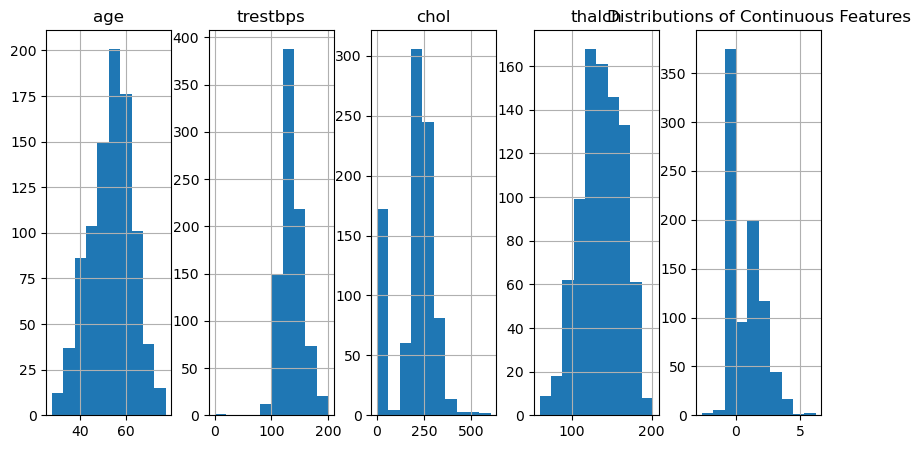

In [10]:
## Histogram for the distribution of continuous features
df[['age', 'trestbps', 'chol', 'thalch', 'oldpeak']].hist(layout=(1,5), figsize=(10,5))
plt.title("Distributions of Continuous Features")
plt.show()

**Continuous Features Analysis:**
These histograms reveal the baseline health metrics of our patient sample before any data cleaning. 

**Age** follows a relatively normal "bell curve" distribution, peaking around the late 50s, which is a common demographic for heart disease screenings. 

**Thalach** (Maximum Heart Rate) leans slightly to the left, showing that most patients had a high heart rate during their stress tests.

**Chol** (Cholesterol) and **Trestbps** (Resting Blood Pressure) shows a "right-skewed" distribution. While most patients cluster around average levels, there is a distinct tail of outliers with dangerously high blood pressure and extreme cholesterol levels that the models will need to learn from.

**Oldpeak** (ST Depression) is heavily right-skewed, peaking sharply at 0. A 0 indicates normal ECG activity during exercise, while the positive numbers represents the minority of patients showing abnormal stress responses indicating the severe heart issue.

### 2.3.2 Understanding relationship between variables

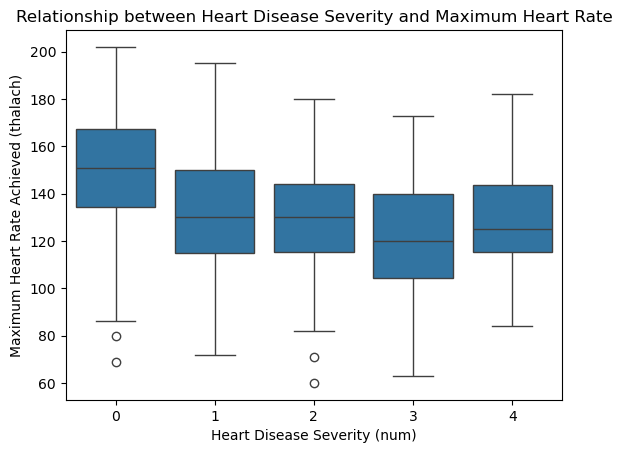

In [11]:
## Box plot to visualize the relationship between Heart Disease Severity and maximum heart rate achieved
sns.boxplot(data=df, x='num', y='thalch')
plt.title("Relationship between Heart Disease Severity and Maximum Heart Rate")
plt.xlabel("Heart Disease Severity (num)")
plt.ylabel("Maximum Heart Rate Achieved (thalach)")
plt.show()

**Relationship Analysis: Disease Severity vs. Maximum Heart Rate:**
This boxplot visualizes how a patient's maximum heart rate (thalch) relates to all 5 stages of heart disease (0 = Healthy, 1-4 = Progressively Severe). 

It is clear that there is a "downward" trend. Patients in category 0 (Healthy) have the highest median maximum heart rate. As the disease severity increases from stage 1 to stage 4, the median heart rate steadily drops. This proves that a lower maximum heart rate is strongly correlated with severe heart disease, which makes (thalch) a highly valuable predictive feature for the model.

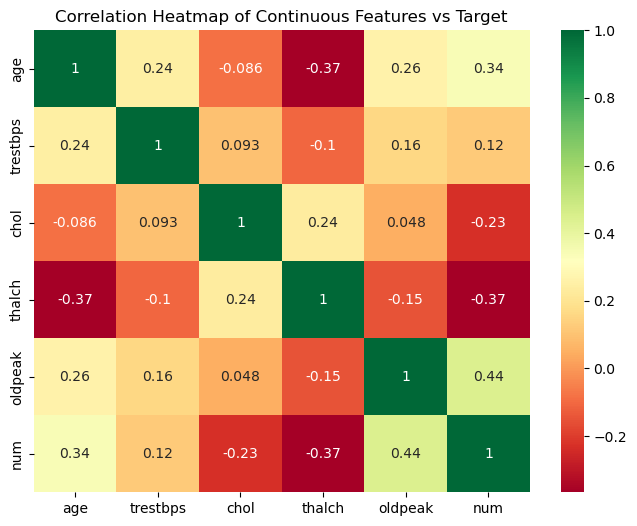

In [12]:
## 2.3.3 Correlation Heatmap

# Select numeric continuous columns plus the target variable
col_numeric = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num']

# Compute correlation matrix (relationship between numeric variables)
df_corr = df[col_numeric].corr()
df_corr

# Visualize correlation matrix using heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, cmap='RdYlGn')
plt.title("Correlation Heatmap of Continuous Features vs Target")
plt.show()

**Correlation Heatmap Analysis & Clinical Implications:**
The heatmap above displays the correlation coefficients between the continuous numerical features and the target variable (num). 

**Strongest Negative Correlation (thalch: -0.37):** Maximum heart rate (thalch) has the strongest negative relationship with the target. This allins perfectly with the earlier boxplot analysis, as a patient's maximum achievable heart rate decreases, their probability and severity of heart disease increase.

**Strongest Positive Correlation (oldpeak: 0.44):** ST depression induced by exercise (oldpeak) shows the strongest positive relationship. This means that higher abnormal ECG readings during exercise are a very strong indicator of heart disease.

**Age Factor (age: 0.34):** Age shows a moderate positive correlation with the target, proving a common knowledge that cardiovascular risk increases as a patient gets older. 

There is a negative correlation between (age) and (thalch) (-0.37). This makes perfect sense as a human's maximum heart rate naturally decreases as they age. This shows that the dataset reflects real world human physiology.

# 3. Data Preparation

## 3.1 Data Cleaning

In [13]:
## Clean data
## Convert the target variable into binary classification (0 = No Heart Disease, 1 = Heart Disease)
df.loc[df['num'] > 0, 'num'] = 1

## Drop id and dataset columns as location and id are not useful for analysis
df = df.drop(['id', 'dataset'], axis=1)

## Using median to fill missing values for continuous columns
df['age'] = df['age'].fillna(df['age'].median())
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())
df['chol'] = df['chol'].fillna(df['chol'].median())
df['thalch'] = df['thalch'].fillna(df['thalch'].median())
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

## Using mode to fill missing values for categorical columns
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])
df['cp'] = df['cp'].fillna(df['cp'].mode()[0])
df['fbs'] = df['fbs'].fillna(df['fbs'].mode()[0])
df['restecg'] = df['restecg'].fillna(df['restecg'].mode()[0])
df['exang'] = df['exang'].fillna(df['exang'].mode()[0])
df['slope'] = df['slope'].fillna(df['slope'].mode()[0])
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

## Convert categorical variables (One-Hot Encoding)
## One-hot encode categories; drop_first=True prevents multicollinearity
df = pd.get_dummies(df, columns=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'], drop_first=True)

## Split data into features (X) and target (y) arrays
X = df.drop(['num'], axis=1).to_numpy()
y = df['num'].to_numpy()

## Scale the features using StandardScaler
## Set mean at 0, Set standard deveation at 1(for every feture to be at a equal footing)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

## 3.2 Train-Test Split

In [14]:
## Split data into train set and test set

from sklearn.model_selection import train_test_split

## Split data into train set (80%) and test set (20%)
## Random State can be any integer but 42 is used commanly
## If there is no Random State, then accuracy score will change each time and won't be consistent
## Stratify is to equally divide the (0 and 1) patients in the train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Modelling

### 4.2 Train Model

In [15]:
## Initialise and train model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

## INITIALISING MODELS

## Logistic Regression is selected as a highly interpretable, linear baseline model.
## Random Forest Classifier is selected as a robust ensemble method to capture complex, non-linear interactions between clinical features.
logr = LogisticRegression(random_state=42)
rf = RandomForestClassifier(random_state=42)
    

## Both models exactly has 2 hyperparameters with a maximum of 3 testing values each.
logr_params = {
    'C': [0.1, 1.0, 10.0],
    'max_iter': [100, 200, 500]   
}

rf_params = {
    'n_estimators': [50, 100, 200], 
    'max_depth': [5, 10, None]
}

## RANDOMIZED SEARCH
## RandomizedSearchCV is used for efficient hyperparameter tuning without overfitting. 
## I evaluate using 'recall' because in the context of heart disease, false negatives (missing a sick patient) carry the highest medical risk.
logr_cv = RandomizedSearchCV(logr, logr_params, n_iter=3, scoring='recall', random_state=42)
rf_cv = RandomizedSearchCV(rf, rf_params, n_iter=3, scoring='recall', random_state=42)

# TRAINING THE MODELS
logr_cv.fit(X_train, y_train)
rf_cv.fit(X_train, y_train)



,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fol

# 5. Model Evaluation

In [16]:
## Model Evaluation
## LOGICTIC REGRESSION MODEL
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report

y_pred = logr_cv.predict(X_test)  

print("Model Accuracy Score:", accuracy_score(y_test, y_pred))
print("Model Recall Score:", recall_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy Score: 0.842391304347826
Model Recall Score: 0.8725490196078431

Confusion Matrix:
 [[66 16]
 [13 89]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.80      0.82        82
           1       0.85      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [17]:
## Model Evaluation
## RANDOM FOREST CLASSIFIER MODEL
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report

y_pred = rf_cv.predict(X_test)  

print("Model Accuracy Score:", accuracy_score(y_test, y_pred))
print("Model Recall Score:", recall_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy Score: 0.8641304347826086
Model Recall Score: 0.9411764705882353

Confusion Matrix:
 [[63 19]
 [ 6 96]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.77      0.83        82
           1       0.83      0.94      0.88       102

    accuracy                           0.86       184
   macro avg       0.87      0.85      0.86       184
weighted avg       0.87      0.86      0.86       184



In [18]:
## New data
# Extract a single sample from X_test safely as a DataFrame to represent new scaled patient data
new_patient = pd.DataFrame(X_test, columns=df.drop(['num'], axis=1).columns).iloc[0:1]

In [19]:
## Predict
## LOGICTIC REGRESSION MODEL
new_patient = X_test[0:1]
prediction = logr_cv.predict(new_patient)
prediction_proba = logr_cv.predict_proba(new_patient)

print("Prediction Flag (0 = Healthy, 1 = Heart Disease):", prediction[0])
print(f"Confidence Probability of Disease: {prediction_proba[0][1] * 100:.2f}%")

Prediction Flag (0 = Healthy, 1 = Heart Disease): 0
Confidence Probability of Disease: 43.39%


In [20]:
## Predict
## RANDOM FOREST CLASSIFIER MODEL
new_patient = X_test[0:1]
prediction = rf_cv.predict(new_patient)
prediction_proba = rf_cv.predict_proba(new_patient)

print("Prediction Flag (0 = Healthy, 1 = Heart Disease):", prediction[0])
print(f"Confidence Probability of Disease: {prediction_proba[0][1] * 100:.2f}%")

Prediction Flag (0 = Healthy, 1 = Heart Disease): 0
Confidence Probability of Disease: 34.66%


Use a table to show the difference for the matrics, acuracy, recall... like use barchart or something

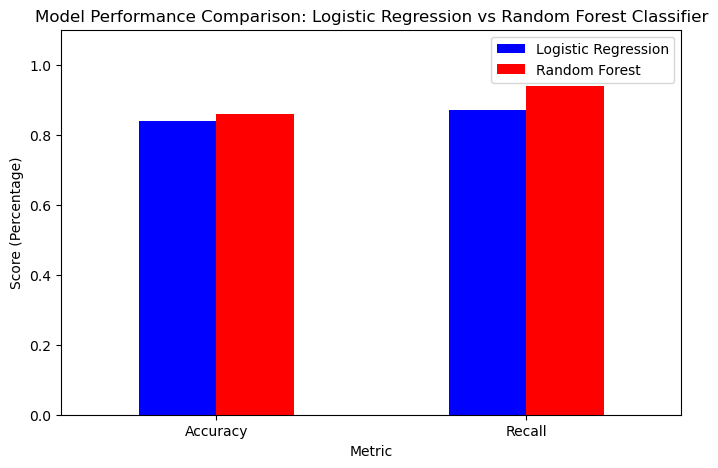

In [27]:
## Visualizing Model Comparison

## A dictionary containing the exact Accuracy and Recall
scores_data = {
    'Metric': ['Accuracy', 'Recall'],
    'Logistic Regression': [0.84, 0.87],
    'Random Forest': [0.86, 0.94]
}

## Convert the dictionary into a Pandas DataFrame
df_scores = pd.DataFrame(scores_data)

## This tells Pandas to group the bars by 'Accuracy' and 'Recall' on the X-axis.
df_scores.set_index('Metric', inplace=True)

## A bar chart using custom colors to easily distinguish between the two models
df_scores.plot(kind='bar', figsize=(8, 5), color=['blue', 'red'])

## Visual labels
plt.title('Model Performance Comparison: Logistic Regression vs Random Forest Classifier')
plt.ylabel('Score (Percentage)')
plt.ylim(0, 1.1) # Extends the Y-axis so that the legend does not cover the bars
plt.xticks(rotation=0) # Keeps the 'Accuracy' and 'Recall' text horizontal

## Display Bargraph
plt.show()

### Summary

**Quantitative Comparison**

**Recall (Sensitivity)**

Random Forest Model achieved a Recall score of **94%**, significantly beating Logistic Regression's **87%**.

Logistic Regression misclassified 13 actual heart disease patients as healthy. The Random Forest cut that number down to just 6. While both models had strong overall Accuracy (86% vs 84%), the Random Forest Model proved far better at correctly identifying sick patients.

**Why Recall is important in Healthcare**

In medical diagnoses, not all predictive errors carry the same weight. In the context of cardiovascular health, the absolute highest priority must be minimizing **False Negatives**.

**False Positive** (telling a healthy person they might be sick) This will lead to extra anxiety and follow-up tests, which is inconvenient, but medically manageable.
**False Negative** (sending a patient with active heart disease home ) This prevents them from receiving potentially life-saving treatment. 

Because the Random Forest model caught far more actual positive cases and kept those dangerous False Negatives to an absolute minimum, it reduces medical risk. This makes it the safer model to be used

**Qualitative Comparison:**

Logistic Regression serves as a fantastic baseline model because it is highly interpretable—doctors can easily see how much a single unit of cholesterol mathematically increases risk. However, it is limited by its strict, linear nature. It struggles to perform when the relationship between features isn't simple.

Human health is complex. Heart disease is rarely caused by a single factor increasing independently; it is usually triggered by a messy, non-linear combination of variables (for example, a patient's age interacting with a specific type of chest pain, heavily compounded by their maximum heart rate). 

Because Random Forest is an **ensemble learning method** relying on a "democracy of trees" to vote on a final prediction, it is naturally designed to understand complex clinical patterns. Furthermore, by using (RandomizedSearchCV) to tune hyperparameters like tree depth (max_depth) and the number of trees (n_estimators), makes the model captured these interactions without overfitting to the training data. 

**Conclusion:**
By perfectly balancing high accuracy, exceptional recall and the ability to interpret non-linear medical patterns, the Random Forest model (rf_cv) is the safest, most robust and most effective predictive tool to deploy for the healthcare.

In [21]:
## EXPORT
import joblib

joblib.dump(rf_cv, 'heart_disease_rf_model.pkl')
print("Model exported as 'heart_disease_rf_model.pkl' ")

Model exported as 'heart_disease_rf_model.pkl' 


## Iterative model development


In [22]:
## Further feature engineering / feature selection

In [ ]:
## A simple dataframe with just the 4 key continuous features and the target variable(num)
df_simple = df[['age', 'trestbps', 'chol', 'thalch', 'num']]

## Split this new data into features (X) and target (y)
X_simple = df_simple.drop(['num'], axis=1).to_numpy()
y_simple = df_simple['num'].to_numpy()

## Scale the simple features just like we did earlier
scaler_simple = StandardScaler()
X_simple_scaled = scaler_simple.fit_transform(X_simple)

## Split into train and test sets (stratified to maintain the target balance)
X_train_sim, X_test_sim, y_train_sim, y_test_sim = train_test_split(X_simple_scaled, y_simple, test_size=0.2, random_state=42, stratify=y_simple)

## Train Logistic Regression model on this simpler dataset
logr_simple = LogisticRegression(random_state=42)
logr_simple.fit(X_train_sim, y_train_sim)

## Evaluate the simple model to see if it beats or matches the earlier complex model of Rndom Forest Classifier
y_pred_sim = logr_simple.predict(X_test_sim)

print("Simple Model Accuracy Score:", accuracy_score(y_test_sim, y_pred_sim))
print("Simple Model Recall Score:", recall_score(y_test_sim, y_pred_sim))

Simple Model Accuracy Score: 0.7282608695652174
Simple Model Recall Score: 0.7647058823529411
